Slope stability case is usually Case 2 (student-t)

References:
- DIN 4084
- Prof. Nagel's teaching script 'slope_stability.ipynb'

In [2]:
import numpy as np 
from numpy import degrees
import sympy as sp
sp.init_printing(use_latex='mathjax')
from scipy.optimize import fsolve
from math import radians, tan, sqrt, atan, degrees
from scipy.stats import t
from itertools import product
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import linregress


""" 
Bishop's simplified method of slices

Geometry 

Let the slope have a vertical height $H$ and the slope angle $\beta$. The geometry of the slope is then given by:

* Foot: F = [0,0]
* Shoulder: S = [H /tan (beta), H]

Assumptions / Limitations

* Dry soil
* Slip circle through foot

"""

# Slope geometry
H_0 = 20

# Soil properties
c_0 = 2  # cohesion
phi_degree_0 = 30
phi_radian_0 = radians(phi_degree_0) # friction angle
gamma_0 = 18  # unit weight

# Parameter to calculate characteristic value
phi_cov_0 = 0.1
phi_theta_0 = 0.01  # first default theta
c_cov_0 = 0.4
c_theta_0 = 0.01  # first default theta
Case = 2
gamma_phi = 1.25  # partial factor, BS-P
gamma_c = 1.25    # partial factor, BS-P
n_0 = 30
beta = radians(27)


In [3]:
# calculate half the central angle of the slip circle
def get_alpha_r(x, z, H, xB):  
    MFl = np.array([-x,-z])   # these are the vectors
    FBl = np.array([xB(x,z),H])
    MBl = FBl + MFl
    return np.arccos(np.dot(MFl,MBl)/(np.linalg.norm(MFl)*np.linalg.norm(MBl))) / 2

# Each circle must pass through the foot (F) and not intersect the slope surface, circles must not intersect slope itself
def is_valid_circle(x,z,beta,H,xB):
    return (xB(x,z) >= H/np.tan(beta))

def run_analysis(phi, c, beta, H, gamma):
    Radius = lambda x, z: np.sqrt(x**2 + z**2)  # calculated by pythogora's theorem
    xB = lambda x, z: x+np.sqrt(Radius(x,z)**2 - (z-H)**2)  #  x-coordinate of a point on the slip surface or circle boundary, y-coordinate is H

    # Creates a grid of potential slip circle centers, each circle must pass through the foot (F) and not intersect the slope surface 
    Mx = np.linspace(-H,H/np.tan(beta),30)
    Mz = np.linspace(0.8*H, 4*H, 20)

    # Record the x-coordinate, z-coordinate of circle center with lowest safety, and the arc of failure plane
    x_max = 0     
    z_max = 0     
    l_max = 0
    etas = np.zeros((len(Mz),len(Mx)))
    mu_max = 0  
    eta_min = 9999
    # List all possible x and z, it is obtained by enumerating Mx and Mz
    for j,x in enumerate(Mx):
        for i,z in enumerate(Mz):
            if (not is_valid_circle(x,z,beta, H, xB)):
                etas[i,j] = None
            else:
                # Geometrie
                r = Radius(x,z)
                MF = np.array([-x,-z])              # vector from the slip circle center M to the foot F, sunce F is at [0,0]
                FB = np.array([xB(x,z),H])          # Vector from the foot F to the exit point B of the slip circle on the slope surface.
                MB = FB + MF                        # Vector from the slip circle center M to the exit point B.
                FS = np.array([H/np.tan(beta),H])   # Vector from the foot F to the shoulder S (top of the slope)
                MS = FS + MF                        # Vector from the slip circle center M to the shoulder S.
                MP = lambda psi: np.array([r * np.sin(psi),-r*np.cos(psi)]) #P liegt auf Gleitkreis  #Parametric equation for a point P on the slip circle (angle psi from vertical)
                SP = lambda psi: MP(psi) - MS       # Vector from shoulder S to point P on the slip circle.
                MC = lambda psi: MS + 2./3. * SP(psi) #C ist Lamellenschwerpunkt. # Approximates the centroid (C) of a slice (assumes triangular slices)
                int_angle = lambda a, b: np.arccos(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)))   # Computes the angle between two vectors a and b
                alpha_r = get_alpha_r(x,z, H,xB)          # Half of the central angle subtended by the slip circle arc (from F to B)

                #Flächenintegral
                alpha_0 = np.arctan(-x/z)                   # Starting angle to point F.
                alpha_1 = alpha_0 + 2.*alpha_r              # Ending angle to point B.
                alphas = np.linspace(alpha_0,alpha_1,50)   # Discretizes the slip circle into 100 slices.
                A = 0                                       # total area of sliding mass
                eA = 0                                      # weighted area for moment calculation
                for ii in range(1,len(alphas)):
                    r_0 = np.linalg.norm(SP(alphas[ii-1]))                 # Distance from S to the start of the slice
                    r_1 = np.linalg.norm(SP(alphas[ii]))                   # Distance from S to the end of the slice.
                    dpsi = int_angle(SP(alphas[ii-1]),SP(alphas[ii]))      # Angle between two consecutive slice edges
                    dA = (r_0+r_1)**2/8 * dpsi                             # Approximate area of the slice (trapezoidal rule in polar coordinates)
                    A += dA                                                # accumulates total area
                    e = MC((alphas[ii]+alphas[ii-1])/2)[0]                 # X-coordinate of the centroid of the slice (for moment calculation)
                    eA += dA*e                                             # accumulates weighted area for moment
                e = eA/A                                                   # Average moment arm (horizontal distance from centroid to axis of rotation).
                F = gamma * A                                              # Total weight of the sliding mass (γ × Area)
                MT = F * e                                                 # Driving moment due to the weight of the sliding mass

                # Kohäsiver Anteil
                l_FB = np.linalg.norm(FB)                                         # Scalar length of the slip surface from F to B (just a straight line)
                rc = alpha_r / np.sin(alpha_r) * r                                # Lever arm for cohesive moment (geometric factor)
                beta_F = np.arctan(FB[1]/FB[0])                                   # Angle of the slip surface FB w.r.t. horizontal
                Fc = np.array([c*l_FB*np.cos(beta_F),c*l_FB*np.sin(beta_F)])      # Cohesive force vector (components in x and z directions)
                MFc = c*l_FB * rc                                                 # Resisting moment due to cohesion (c × length × lever arm)

                # Total net sliding force (alte Norm)
                Q = -np.array([0,-F]) - Fc                                        # Net force acting on the slip surface (weight: x-axis =0, y-axis = F minus cohesive force Fc).

                xi = (1+alpha_r/np.sin(alpha_r))/2                                # Empirical factor (Bishop’s correction for circular slip surfaces).

                # Startwert: alte Norm
                mu_0 = MT / (MFc + np.linalg.norm(Q) * xi * Radius(x,z)*np.sin(phi))     # Initial guess for the load factor μ (safety factor η = 1/μ)
                
                # Limit state function
                #f_test = lambda mu_i: (MT - np.linalg.norm(-np.array([0,-F]) - mu_i * Fc) * xi * Radius(x,z)*np.sin(np.arctan(mu_i * np.tan(phi))))/(MFc * mu_i) - 1
                f_test = lambda mu_i: (MT)/(MFc * mu_i + np.linalg.norm(-np.array([0,-F]) - mu_i * Fc) * xi * Radius(x,z)*np.sin(np.arctan(mu_i * np.tan(phi)))) - 1  # Equations (7)–(10) of DIN 4084
                
                # matches the iterative format from Equations (7)–(10) of DIN 4084
                mu_1 = fsolve(f_test,mu_0)[0]     # Mobilized force ratio
                eta = 1/mu_1                      # Factor of Safety

                # Store all safety factors in the etas array, tracks the circle with the lowest safety factor (threshold failure surface)
                etas[i,j] = eta   # store all safety factors in the etas array

                if  eta < eta_min:
                    eta_min = eta
                    x_max = x
                    z_max = z
                    l_max = r * 2 * alpha_r

    return eta_min, l_max,  x_max, z_max
            
def characteristic_value(mean, cov, theta, L, Case , n) :
    
    # Adjust gamma_sq based on estimate type (Vanmarcke's)
    if L <= theta:
        gamma_sq = 1  # Case B,  Failure tends to be local and the mobilized value distribution resembles the underlying distribution (no averaging)
    else:  # Case C, mobilized value distribution becomes narrower due to variance reduction, mean is reduced due to weak zone seeking; 
        # When theta/L gets so small, it eventually tends to be 0, which is the case A (Consider averaging of soil property value, which leads to narrower mobilized value distribution, centered along the mean of the underlying distribution)
        gamma_sq = theta/L
    
    N95 = 1.645
    t95 =  t.ppf(0.95, n-1)

    # Determine k_n based on case and estimate type
    if Case == "1"or Case =="3":  # case 1, V_X known; case 3, V_X unknown
        k_n = N95 * sqrt(gamma_sq + 1 / n)
    else:  # case 2, V_X unknown
        k_n = t95 * sqrt(gamma_sq + 1 / n)
    
    # Calculate characteristic value
    X_k = mean * (1 - k_n * cov)   

    return X_k

In [4]:
# We get the length of the failure plane
l_arc =  run_analysis(phi_radian_0,c_0, beta, H_0, gamma_0)[1]    # we assume it is the truth

# Calculate characteristic value
phi1_k = characteristic_value (phi_degree_0, phi_cov_0, phi_theta_0, l_arc, Case, n_0) 
c_k = characteristic_value (c_0, c_cov_0, c_theta_0, l_arc, Case, n_0)

# Calculate the design value
phi1_d = atan(tan(radians(phi1_k)) / gamma_phi)  # in radians
c_d = c_k / gamma_c

# We rerun the analysis to get the eta (safety factor)
eta =  run_analysis(phi1_d,c_d, beta,H_0, gamma_0)[0]


In [ ]:
l_arc

In [5]:
eta

0.9872105638786353

In [6]:
# Test a range of theta
theta_range = np.linspace(0.05, 50.05, 10)  # Scale of fluctuation range, 0.3 to 7

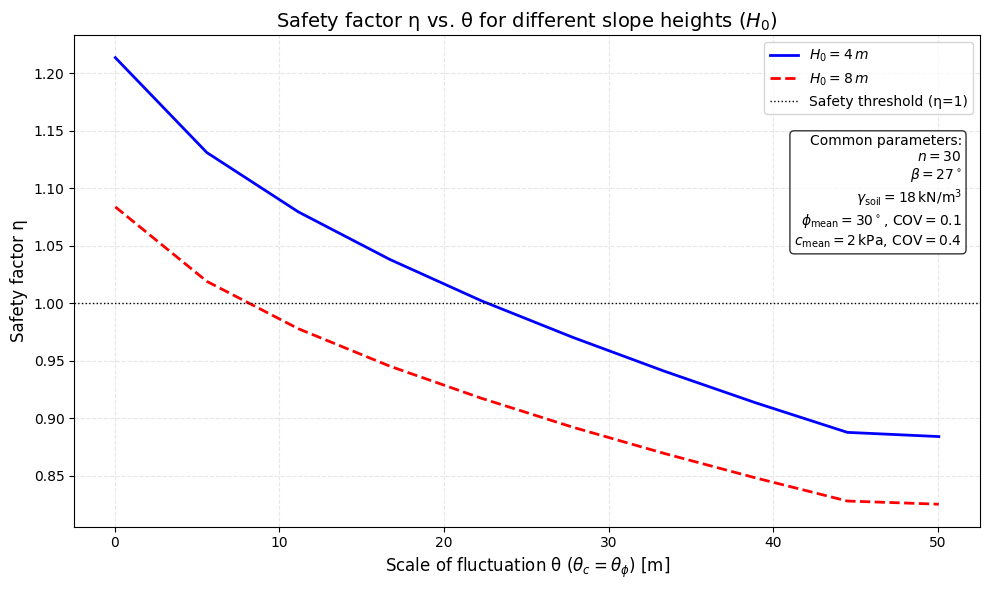

In [7]:
# --- Define parameters ---
H_values = [4, 8]  # Example slope heights
colors = ['b', 'r']  # Colors for the two lines
line_styles = ['-', '--']  # Solid and dashed lines


# --- Plot setup ---
plt.figure(figsize=(10, 6))

# --- Loop over each H_0 and compute eta ---
for H_0, color, ls in zip(H_values, colors, line_styles):
    eta_values = np.zeros_like(theta_range)
    
    for i, theta in enumerate(theta_range):
        theta_phi = theta
        theta_c = theta  # Same as theta_phi
        
        phi1_k = characteristic_value(phi_degree_0, phi_cov_0, theta_phi, l_arc, Case, n_0)
        c_k = characteristic_value(c_0, c_cov_0, theta_c, l_arc, Case, n_0)
        
        phi1_d = np.arctan(np.tan(radians(phi1_k)) / gamma_phi)  # in radians
        c_d = c_k / gamma_c
        
        eta_values[i] = run_analysis(phi1_d, c_d, beta, H_0, gamma_0)[0]
    
    # Plot the line for this H_0
    plt.plot(theta_range, eta_values, color=color, linestyle=ls, linewidth=2,
             label=rf'$H_0 = {H_0}\,m$')

# --- Safety threshold line ---
plt.axhline(y=1.0, color='k', linestyle=':', linewidth=1, label='Safety threshold (η=1)')

# --- Formatting ---
plt.xlabel(r'Scale of fluctuation θ ($\theta_c = \theta_\phi$) [m]', fontsize=12)
plt.ylabel('Safety factor η', fontsize=12)
plt.title('Safety factor η vs. θ for different slope heights ($H_0$)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='best')

# --- Parameter box (excluding H_0 since it's in the legend) ---
param_text = (
    r"Common parameters:" + "\n" +
    rf"$n={n_0}$" + "\n" +
    rf"$\beta={degrees(beta):.0f}^\circ$" + "\n" +
    rf"$\gamma_\mathrm{{soil}}={gamma_0}\,\mathrm{{kN/m^3}}$" + "\n" +
    rf"$\phi_\mathrm{{mean}}={phi_degree_0}^\circ$, $\mathrm{{COV}}={phi_cov_0}$" + "\n" +
    rf"$c_\mathrm{{mean}}={c_0}\,\mathrm{{kPa}}$, $\mathrm{{COV}}={c_cov_0}$"
)

plt.text(0.98, 0.8, param_text, transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.tight_layout()
plt.show()


[[1.08384616 1.04278464 1.01737907 0.99739182 0.98043271 0.96539048
  0.95170498 0.93914718 0.9274897  0.92589316]
 [1.05972398 1.01904323 0.99363731 0.97364978 0.95669041 0.94173387
  0.92822798 0.91583499 0.9043305  0.9027549 ]
 [1.04357234 1.00295986 0.9778321  0.9580634  0.9412897  0.92649691
  0.91313888 0.90088156 0.88939945 0.88782384]
 [1.03056309 0.99011337 0.96498545 0.94521662 0.92844281 0.91364991
  0.90029178 0.88803437 0.87665574 0.87509738]
 [1.01867188 0.97842913 0.95353011 0.93394136 0.91732035 0.90265352
  0.88929532 0.87703784 0.86565914 0.86410077]
 [1.00802727 0.96786352 0.94296438 0.92337553 0.90675443 0.8920962
  0.87885968 0.86671386 0.85543881 0.85389464]
 [0.99790079 0.95791539 0.93312899 0.9136288  0.89708292 0.88249101
  0.86925551 0.85710963 0.84583453 0.84429035]
 [0.9883172  0.94837758 0.9236661  0.90422488 0.88772904 0.87318129
  0.86003627 0.8479454  0.83672134 0.83518416]
 [0.97898618 0.93929633 0.91472116 0.89527987 0.87878397 0.86423615
  0.85109934 

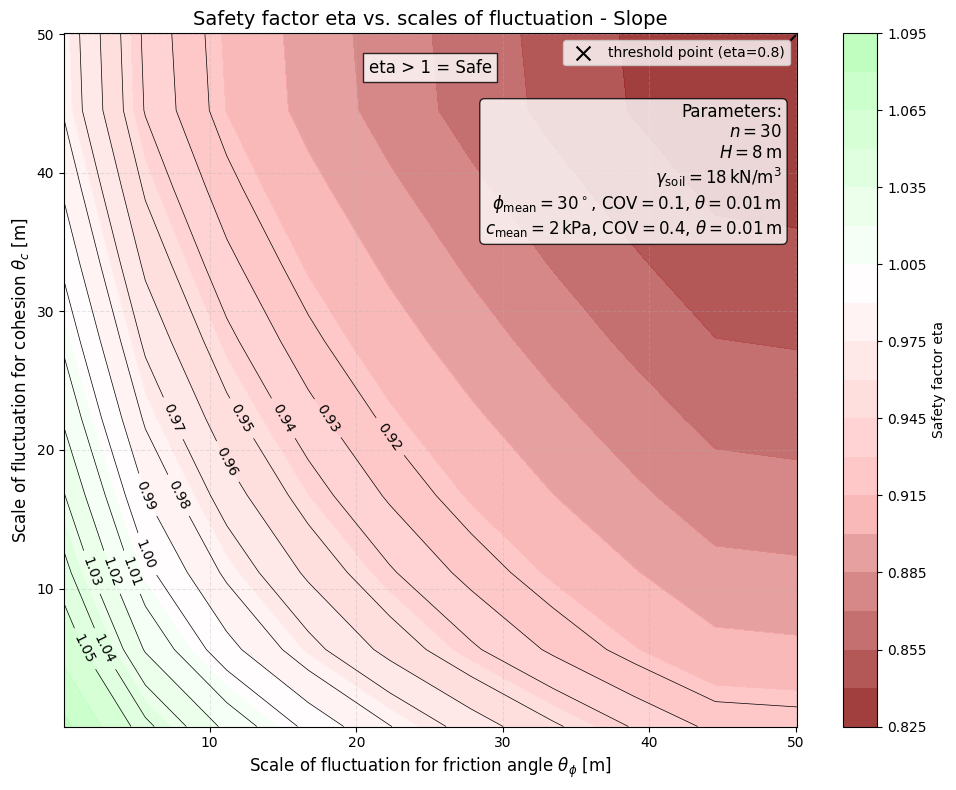

In [8]:
# Define parameter ranges
theta_phi_grid, theta_c_grid = np.meshgrid(theta_range, theta_range)

# Calculate eta values for all combinations
eta_values = np.zeros_like(theta_phi_grid)
for i in range(len(theta_range)):
    for j in range(len(theta_range)):
        
        theta_phi = theta_phi_grid[i,j]
        theta_c = theta_c_grid[i,j]

        phi1_k = characteristic_value (phi_degree_0, phi_cov_0, theta_phi, l_arc, Case, n_0)
        c_k = characteristic_value (c_0, c_cov_0, theta_c, l_arc, Case, n_0)

        phi1_d = atan(tan(radians(phi1_k)) / gamma_phi)     # in radians
        c_d = c_k / gamma_c

        eta_values[i,j]  = run_analysis (phi1_d, c_d, beta,H_0, gamma_0) [0]

print (eta_values)

# Create the plot
plt.figure(figsize=(10, 8))

# --- Symmetric Normalization Around 1 ---
eta_min, eta_max = np.min(eta_values), np.max(eta_values)
center_value = 1.0  # White aligns here
delta = max(center_value - eta_min, eta_max - center_value)
vmin, vmax = center_value - delta, center_value + delta  # Symmetric around η=1

# Create custom colormap: red (unsafe) -> white (G=0) -> green (safe)
colors = [
    (0.5, 0.0, 0.0),  # Deep red
    (1.0, 0.7, 0.7),  # Light red (near zero)
    (1, 1, 1),        # Pure white at zero
    (0.7, 1.0, 0.7),  # Light green (near zero)
    (0.0, 0.5, 0.0)   # Deep green
]
cmap_custom = LinearSegmentedColormap.from_list('danger_safe', colors, N=256)


# Create contour plot
contour = plt.contourf(theta_phi_grid, theta_c_grid, eta_values, levels=20, cmap=cmap_custom, alpha=0.8, vmin=vmin, vmax=vmax)
plt.colorbar(contour, label='Safety factor eta')

# Add contour lines
CS = plt.contour(theta_phi_grid, theta_c_grid, eta_values, 
                levels=[0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.00, 1.01, 1.02, 1.03, 1.04,  1.05], colors='black', linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10)

# Highlight the threshold point (minimum eta)
min_idx = np.unravel_index(np.argmin(eta_values), eta_values.shape)
plt.scatter(theta_phi_grid[min_idx], theta_c_grid[min_idx], 
           color='black', marker='x', s=100, label=f'threshold point (eta={eta_values[min_idx]:.1f})')

# Formatting
plt.xlabel(r'Scale of fluctuation for friction angle $\theta_\phi$ [m]', fontsize=12)
plt.ylabel(r'Scale of fluctuation for cohesion $\theta_c$ [m]', fontsize=12)
plt.title('Safety factor eta vs. scales of fluctuation - Slope', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

# Add text annotation about safety
plt.text(0.5, 0.95, 'eta > 1 = Safe', transform=plt.gca().transAxes,
        ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))


#Add parameter list as text box (upper right corner)
param_text = (
    r"Parameters:" + "\n" +
    rf"$n={n_0}$" + "\n" +
    rf"$H={H_0}\,\mathrm{{m}}$" + "\n" +
    rf"$\gamma_\mathrm{{soil}}={gamma_0}\,\mathrm{{kN/m^3}}$" + "\n" +
    rf"$\phi_\mathrm{{mean}}={phi_degree_0}^\circ$, $\mathrm{{COV}}={phi_cov_0}$, $\theta={phi_theta_0}\,\mathrm{{m}}$" + "\n" +
    rf"$c_\mathrm{{mean}}={c_0}\,\mathrm{{kPa}}$, $\mathrm{{COV}}={c_cov_0}$, $\theta={c_theta_0}\,\mathrm{{m}}$"
)

plt.text(0.98, 0.9, param_text, transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))


plt.tight_layout()

plt.show()


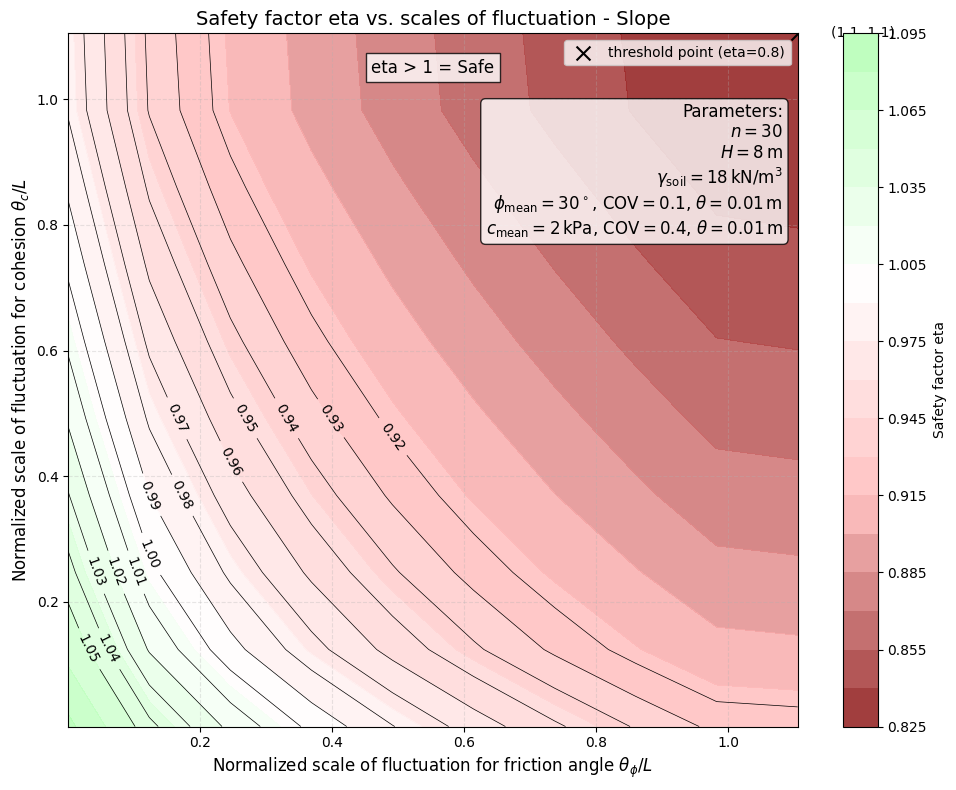

In [ ]:
# Create normalized grids (theta/L)
theta_phi_normalized_l = theta_phi_grid / l_arc
theta_c_normalized_l = theta_c_grid / l_arc

# Create the plot
plt.figure(figsize=(10, 8))

x_coord = theta_phi_normalized_l[min_idx]
y_coord = theta_c_normalized_l[min_idx]

# Create contour plot
contour = plt.contourf(theta_phi_normalized_l, theta_c_normalized_l, eta_values, levels=20, cmap=cmap_custom, alpha=0.8, vmin=vmin, vmax=vmax)
plt.colorbar(contour, label='Safety factor eta')

# Add contour lines
CS = plt.contour(theta_phi_normalized_l, theta_c_normalized_l, eta_values, 
                levels=[0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.00, 1.01, 1.02, 1.03, 1.04,  1.05], colors='black', linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10)

# Add text label with coordinate values near the marker
plt.text(x_coord + 0.05, y_coord, f'({x_coord:.1f}, {y_coord:.1f})', color='black', fontsize=10, va='center')

plt.scatter(theta_phi_normalized_l[min_idx], theta_c_normalized_l[min_idx], 
           color='black', marker='x', s=100, label=f'threshold point (eta={eta_values[min_idx]:.1f})')

# Formatting
plt.xlabel(r'Normalized scale of fluctuation for friction angle $\theta_\phi/L$', fontsize=12)
plt.ylabel(r'Normalized scale of fluctuation for cohesion $\theta_c/L$', fontsize=12)
plt.title('Safety factor eta vs. scales of fluctuation - Slope', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

# Add text annotation about safety
plt.text(0.5, 0.95, 'eta > 1 = Safe', transform=plt.gca().transAxes,ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

#Add parameter list as text box (upper right corner)
param_text = (
    r"Parameters:" + "\n" +
    rf"$n={n_0}$" + "\n" +
    rf"$H={H_0}\,\mathrm{{m}}$" + "\n" +
    rf"$\gamma_\mathrm{{soil}}={gamma_0}\,\mathrm{{kN/m^3}}$" + "\n" +
    rf"$\phi_\mathrm{{mean}}={phi_degree_0}^\circ$, $\mathrm{{COV}}={phi_cov_0}$" + "\n" +
    rf"$c_\mathrm{{mean}}={c_0}\,\mathrm{{kPa}}$, $\mathrm{{COV}}={c_cov_0}$"
)

plt.text(0.98, 0.9, param_text, transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.tight_layout()
plt.show()

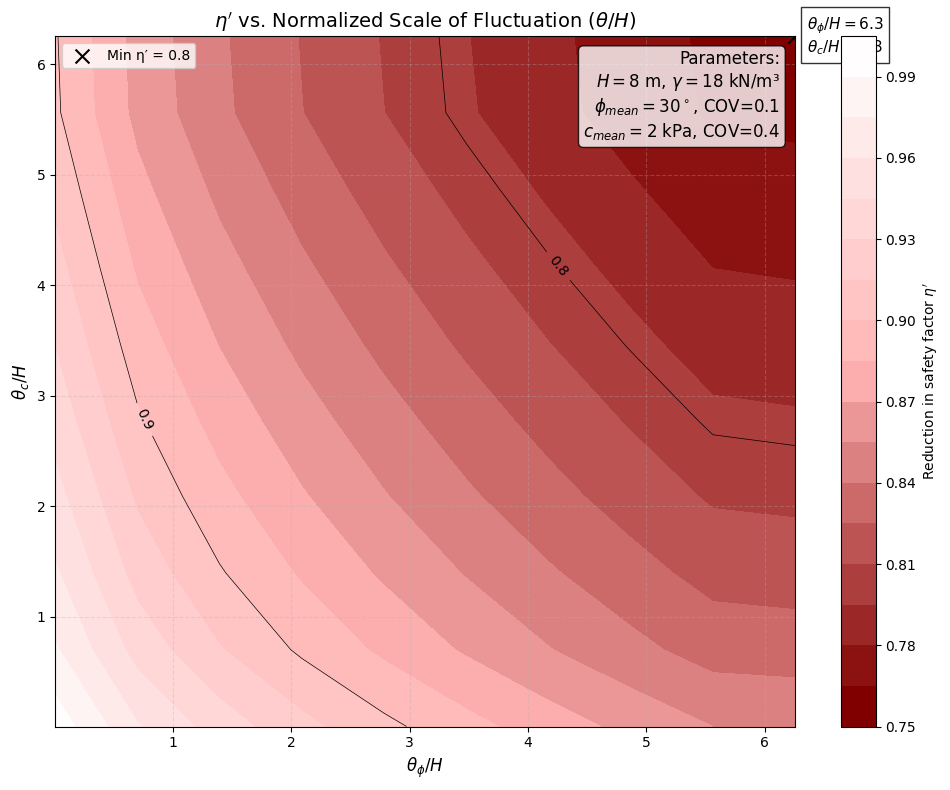

In [10]:
# --- Compute reference eta for large theta (deterministic case - Case B) ---
small_theta = 1e-6

phi1_k_ref = characteristic_value(phi_degree_0, phi_cov_0, small_theta, l_arc, Case, n_0)
c_k_ref = characteristic_value(c_0, c_cov_0, small_theta, l_arc, Case, n_0)

phi1_d_ref = atan(tan(radians(phi1_k_ref)) / gamma_phi)
c_d_ref = c_k_ref / gamma_c

eta_ref = run_analysis(phi1_d_ref, c_d_ref,beta, H_0, gamma_0)[0]

# --- Compute eta′ for each θ combination ---
eta_prime_values = np.zeros_like(theta_phi_grid)
eta_prime_values = eta_values / eta_ref

# --- Normalize theta by H ---
theta_phi_norm = theta_phi_grid / H_0
theta_c_norm = theta_c_grid / H_0

# --- Colormap centered at η′ = 1 ---
eta_min, eta_max = np.min(eta_prime_values), np.max(eta_prime_values)
center_value = 1.0
delta = max(center_value - eta_min, eta_max - center_value)
vmin, vmax = center_value - delta, center_value + delta

colors = [
    (0.5, 0.0, 0.0),  # Deep red
    (1.0, 0.7, 0.7),  # Light red
    (1, 1, 1),        # White
    (0.7, 1.0, 0.7),  # Light green
    (0.0, 0.5, 0.0)   # Deep green
]
cmap_custom = LinearSegmentedColormap.from_list('degradation_map', colors, N=256)

# --- Plot ---
plt.figure(figsize=(10, 8))

contour = plt.contourf(theta_phi_norm, theta_c_norm, eta_prime_values, levels=20,
                       cmap=cmap_custom, vmin=vmin, vmax=vmax)
plt.colorbar(contour, label=r'Reduction in safety factor $\eta^\prime$')

# Contour lines
CS = plt.contour(theta_phi_norm, theta_c_norm, eta_prime_values,
                 levels = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2], colors='black', linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10)

# Threshold point
min_idx = np.unravel_index(np.argmin(eta_prime_values), eta_prime_values.shape)
x_cross = theta_phi_norm[min_idx]
y_cross = theta_c_norm[min_idx]
eta_min_val = eta_prime_values[min_idx]
plt.scatter(theta_phi_norm[min_idx], theta_c_norm[min_idx],
            color='black', marker='x', s=100, label=f'Min η′ = {eta_prime_values[min_idx]:.1f}')

# Labels and formatting
plt.xlabel(r'$\theta_\phi / H$', fontsize=12)
plt.ylabel(r'$\theta_c / H$', fontsize=12)
plt.title(r'$\eta^\prime$ vs. Normalized Scale of Fluctuation ($\theta / H$)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

# Text box
param_text = (
    r"Parameters:" + "\n" +
    rf"$H={H_0}$ m, $\gamma={gamma_0}$ kN/m³" + "\n" +
    rf"$\phi_{{mean}}={phi_degree_0}^\circ$, COV={phi_cov_0}" + "\n" +
    rf"$c_{{mean}}={c_0}$ kPa, COV={c_cov_0}"
)

plt.text(0.98, 0.98, param_text, transform=plt.gca().transAxes,
         ha='right', va='top', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.text(x_cross + 0.1, y_cross, 
         rf"$\theta_\phi/H={x_cross:.1f}$" + "\n" + 
         rf"$\theta_c/H={y_cross:.1f}$",
         fontsize=11, ha='left', va='center',
         bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))

plt.tight_layout()
plt.show()

In [11]:
# from SALib.sample import sobol as sobol_sample
# from SALib.analyze import sobol
# import matplotlib.pyplot as plt

# problem = {
#     "num_vars": 6,
#     "names": [
#         "phi_cov",
#         "c_cov",
#         "theta_phi", 
#         "theta_c",
#         "H",
#         "n",
#     ],

#     "bounds": [
#         [0.05, 0.15],
#         [0.3, 0.5],
#         [1, 7],
#         [1, 7], 
#         [3 , 8],  # slope from 3/9 to 8/9
#         [10, 30]
#     ]
# }

# # --- Generate Sobol samples ---
# N = 512  # base sample size
# param_values = sobol_sample.sample(problem, N, calc_second_order=True)

# # --- Evaluate the model for each sample ---
# def evaluate_model(X):
#     outputs = []
#     for row in X:
#         phi_cov, c_cov, theta_phi, theta_c, H, n= row
#         n = int(round(n))

#         l_arc_SA = run_analysis(phi_radian_0, c_0,beta, H, gamma_0)[1]         # This is the truth (note: l changes with H)   
#         phi_k = characteristic_value (phi_degree_0, phi_cov, theta_phi, l_arc_SA, Case, n)
#         c_k = characteristic_value (c_0, c_cov, theta_c, l_arc_SA, Case, n)

#         phi1_d = atan(tan(radians(phi_k)) / gamma_phi)     # in radians
#         c_d = c_k / gamma_c

#         eta = run_analysis  (phi1_d, c_d,beta, H, gamma_0) [0]
        
#         outputs.append(eta)

#     return np.array(outputs)

# Y = evaluate_model(param_values)
# Y = np.nan_to_num(Y, nan=np.max(Y[np.isfinite(Y)]) )  # Replace nan with large value

# # --- Sobol analysis ---
# Si = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=True)

# # --- Plot S1 ---
# fig1, ax1 = plt.subplots(figsize=(10, 5))
# x_labels = problem["names"]
# x = np.arange(len(x_labels))

# ax1.bar(x, Si["S1"], width=0.4, label="First-order (S1)", color='skyblue')
# ax1.set_ylabel("Sobol Sensitivity Index")
# ax1.set_xticks(x)
# ax1.set_xticklabels(x_labels, rotation=45)
# ax1.set_title("First-order Sobol Sensitivity Indices (S1)")
# ax1.grid(True)
# plt.tight_layout()
# plt.show()

# # --- Plot ST ---
# fig2, ax2 = plt.subplots(figsize=(10, 5))
# ax2.bar(x, Si["ST"], width=0.4, label="Total-order (ST)", color='salmon')
# ax2.set_ylabel("Sobol Sensitivity Index")
# ax2.set_xticks(x)
# ax2.set_xticklabels(x_labels, rotation=45)
# ax2.set_title("Total-order Sobol Sensitivity Indices (ST)")
# ax2.grid(True)
# plt.tight_layout()
# plt.show()


In [12]:
# from matplotlib import cm
# import numpy as np

# # --- Plot S2 (Interaction Effects) ---
# fig3, ax3 = plt.subplots(figsize=(10, 8))

# # Get the S2 matrix
# S2_matrix = Si['S2']

# # Create a mask for the upper triangle (since the matrix is symmetric)
# mask = np.triu(np.ones_like(S2_matrix, dtype=bool))

# # Create a heatmap of the S2 values
# im = ax3.imshow(S2_matrix, cmap=cm.viridis, vmin=0, vmax=0.1) #np.nanmax(S2_matrix)

# # Add colorbar
# cbar = fig3.colorbar(im, ax=ax3)
# cbar.set_label('Second-order Sobol Index')

# # Set ticks and labels
# ax3.set_xticks(np.arange(len(problem['names'])))
# ax3.set_yticks(np.arange(len(problem['names'])))
# ax3.set_xticklabels(problem['names'], rotation=45)
# ax3.set_yticklabels(problem['names'])

# # Add values to each cell
# for i in range(len(problem['names'])):
#     for j in range(len(problem['names'])):
#         if not mask[i,j]:  # Only show lower triangle
#             if not np.isnan(S2_matrix[i,j]):
#                 text = ax3.text(j, i, f"{S2_matrix[i,j]:.2f}",
#                               ha="center", va="center", color="w")

# ax3.set_title("Second-order Sobol Indices (Interaction Effects)")
# plt.tight_layout()
# plt.show()

In [13]:
# import numpy as np
# import matplotlib.pyplot as plt
# import ipywidgets as widgets
# from IPython.display import display

# # Parameter ranges
# theta_vals = theta_range
# cov_vals = np.linspace(0.05, 0.5, 30)
# H_vals = np.linspace(1, 12, 12)

# def plot_eta(vary='theta_phi', theta_phi=5, theta_c=5, cov_phi=0.3, cov_c=0.2, H=6.5):
#     if vary == 'theta_phi':
#         x_vals = theta_vals
#         x_label = r'$\theta_\phi$ (m)'
#     elif vary == 'theta_c':
#         x_vals = theta_vals
#         x_label = r'$\theta_c$ (m)'
#     elif vary == 'cov_phi':
#         x_vals = cov_vals
#         x_label = r'CoV$_{\phi}$'
#     elif vary == 'cov_c':
#         x_vals = cov_vals
#         x_label = r'CoV$_{c}$'
#     elif vary == 'H':
#         x_vals = H_vals
#         x_label = r'Slope Height $H$ (m)'
#     else:
#         return
    
#     eta_vals = []
#     for x in x_vals:
#         try:
#             # Vary one parameter; hold the rest fixed
#             theta_phi_x = x if vary == 'theta_phi' else theta_phi
#             theta_c_x = x if vary == 'theta_c' else theta_c
#             cov_phi_x = x if vary == 'cov_phi' else cov_phi
#             cov_c_x = x if vary == 'cov_c' else cov_c
#             H_x = x if vary == 'H' else H

#             # Run analysis to get arc length
#             l_arc = run_analysis(phi_radian_0, c_0, beta, H_x, gamma_0)[1]

#             # Characteristic values
#             phi_k = characteristic_value(phi_degree_0, cov_phi_x, theta_phi_x, l_arc, Case, n_0)
#             c_k = characteristic_value(c_0, cov_c_x, theta_c_x, l_arc, Case, n_0)

#             # Design values
#             phi_d = atan(tan(np.radians(phi_k)) / gamma_phi)
#             c_d = c_k / gamma_c

#             eta = run_analysis(phi_d, c_d,beta, H_x, gamma_0)[0]
#             eta_vals.append(eta)
#         except:
#             eta_vals.append(np.nan)

#     # Find and annotate threshold point
#     eta_vals = np.array(eta_vals)
#     min_idx = np.nanargmin(eta_vals)
#     x_crit = x_vals[min_idx]
#     eta_crit = eta_vals[min_idx]

#     # Plot
#     plt.figure(figsize=(8, 5))
#     plt.plot(x_vals, eta_vals, marker='o', linestyle='-', color='navy')
#     plt.plot(x_crit, eta_crit, 'ro', label=f'Min η = {eta_crit:.3f}\n@ {x_label} = {x_crit:.2f}')
#     plt.annotate(f'{eta_crit:.3f} at {x_label} = {x_crit:.2f}',
#                  xy=(x_crit, eta_crit),
#                  xytext=(x_crit + (x_vals[-1]-x_vals[0])*0.05, eta_crit + 0.02),
#                  arrowprops=dict(facecolor='red', arrowstyle='->'),
#                  fontsize=10, color='red')

#     plt.xlabel(x_label)
#     plt.ylabel(r'Factor of Safety $\eta$')
#     plt.title(f'Effect of {x_label} on Factor of Safety η')
#     plt.grid(True)
#     plt.ylim(bottom=0.2)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# # Interactive UI
# interact_ui = widgets.interactive(
#     plot_eta,
#     vary=widgets.Dropdown(
#         options=['theta_phi', 'theta_c', 'cov_phi', 'cov_c', 'H'],
#         value='theta_phi',
#         description='Vary:',
#     ),
#     theta_phi=widgets.FloatSlider(min=0.5, max=50, step=0.5, value=5, description='θ_φ'),
#     theta_c=widgets.FloatSlider(min=0.5, max=50, step=0.5, value=5, description='θ_c'),
#     cov_phi=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.3, description='CoV_φ'),
#     cov_c=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.2, description='CoV_c'),
#     H=widgets.FloatSlider(min=1, max=12, step=0.5, value=6.5, description='H (m)'),
# )

# display(interact_ui)


Here we find the relationship between the threshold scale of fluctuation and the slope height. 

In [ ]:
theta_range = np.linspace(0.05, 50.05, 50)  # Scale of fluctuation range, 0.3 to 7
H_vals = np.linspace(1, 12, 12)
l_arc = np.empty_like(H_vals)

def get_threshold_theta_phi_vs_H(theta_vals=theta_range, H_vals=H_vals):
    threshold_theta_phi = []
    l_vals = []
    for H_x in H_vals:
        eta_vals = []
        for theta in theta_vals:
            try:
                # Run analysis to get arc length
                l_arc = run_analysis(phi_radian_0, c_0, beta, H_x, gamma_0)[1]

                # Characteristic values
                phi_k = characteristic_value(phi_degree_0, phi_cov_0, theta, l_arc, Case, n_0)
                c_k = characteristic_value(c_0, c_cov_0, theta, l_arc, Case, n_0)

                # Design values
                phi_d = atan(tan(np.radians(phi_k)) / gamma_phi)
                c_d = c_k / gamma_c

                # Run stability analysis
                eta = run_analysis(phi_d, c_d, beta, H_x, gamma_0)[0]
                eta_vals.append(eta)
                
            except:
                eta_vals.append(np.nan)

        l_vals.append(l_arc)
        eta_vals = np.array(eta_vals)
        min_idx = np.nanargmin(eta_vals)
        threshold_theta_phi.append(theta_vals[min_idx])
    l_vals = np.array(l_vals)
    
    return  l_vals, np.array(H_vals), np.array(threshold_theta_phi)


# Plot

l_vals, H_range, theta_phi_crit = get_threshold_theta_phi_vs_H()

plt.figure(figsize=(8, 5))
plt.plot(H_range, theta_phi_crit, marker='o', linestyle='-', color='darkgreen')
plt.xlabel('Slope Height $H$ (m)')
plt.ylabel(r'Threshold $\theta$ (m)')
plt.title('Threshold scale of fluctuation vs Slope Height $H$')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
l_vals

array([ 2.66550625,  4.96536897,  7.3213265 ,  9.6173723 , 11.86569116,
       14.07532428, 16.42121165, 18.57498561, 20.89685881, 23.21873201,
       25.30595121, 27.60649223])

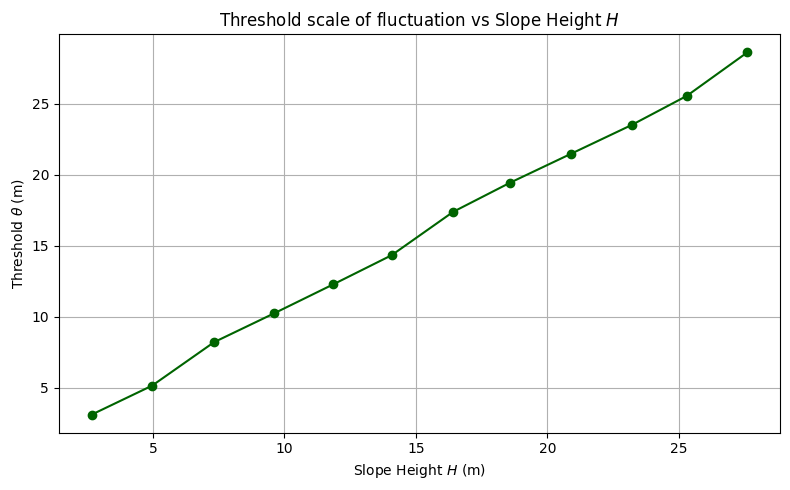

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(l_vals, theta_phi_crit, marker='o', linestyle='-', color='darkgreen')
plt.xlabel('Slope Height $H$ (m)')
plt.ylabel(r'Threshold $\theta$ (m)')
plt.title('Threshold scale of fluctuation vs characteristic length $H$')
plt.grid(True)
plt.tight_layout()
plt.show()
